# Imports

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import openslide
from PIL import Image
import pandas as pd
import ast
import h5py
from zipfile import ZipFile
import cv2
from tqdm import tqdm

from skimage import io
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn

# Hugging Face

In [2]:
import timm
from timm.data import resolve_data_config
from timm.data.transforms_factory import create_transform
from huggingface_hub import login

login()

# Paths

In [2]:
root_data_path = "../../../../../mnt/data/"

# Functions

In [3]:
def keys(f):
    return [key for key in f.keys()]

def show_img(img_path):
    img = io.imread(img_path)
    io.imshow(img)

def get_image_label(img):
    found = [0, 0, 0]
    label = [0, 0, 0]
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            if all(img[i, j] == [0, 64, 128]):
                label[0] = 1
                found[0] = 1
            if all(img[i, j] == [64, 128, 0]):
                label[1] = 1
                found[1] = 1
            if all(img[i, j] == [243, 152, 0]):
                label[2] = 1
                found[2] = 1
            if found == [1, 1, 1]:
                break
        if found == [1, 1, 1]:
            break 

    return label      

def get_wss_features(path):
    features_list = [[],[],[],[],[],[],[]]
    samples = next(os.walk(path))[2]

    for sample in samples:
        img = io.imread(os.path.join(path, sample))
        label = get_image_label(img)
        features_list[0].append(sample[:-4])
        features_list[1].append(None)
        features_list[2].append(None)
        features_list[3].append(label[0])
        features_list[4].append(label[1])
        features_list[5].append(label[2])
        features_list[6].append(label)

    features = pd.DataFrame(features_list).T
    columns = columns=["id", "x-axis", "y-axis", "tumor", "stroma", "normal", "patch_level_multi_class_labels"]
    features.columns = columns
        
    return features

def get_digestpath_features(path):
    features_list = [[],[],[]]
    positive_wsi_positive_patch = next(os.walk(os.path.join(path, "DigestPath/Cancerous_WSI_patches/cancerous_patches")))[2]
    positive_wsi_positive_patch = [patch_id for patch_id in positive_wsi_positive_patch if '_mask' not in patch_id]
    
    positive_wsi_negative_patch = next(os.walk(os.path.join(path, "DigestPath/Cancerous_WSI_patches/non_cancerous_patches")))[2]
    negative_wsi = next(os.walk(os.path.join(path, "DigestPath/Non_Cancerous_WSI_patches/non_cancerous_patches/")))[2]

    data = [positive_wsi_positive_patch, positive_wsi_negative_patch, negative_wsi]

    for i, class_type in enumerate(data):
        for sample in class_type:
            if(i == 0):
                features_list[0].append(f"1_1_{sample[:-4]}")
                features_list[1].append(1)
                features_list[2].append(1)
            elif(i == 1):
                features_list[0].append(f"0_1_{sample[:-4]}")
                features_list[1].append(0)
                features_list[2].append(1)
            elif(i == 2):
                features_list[0].append(f"0_0_{sample[:-4]}")
                features_list[1].append(0)
                features_list[2].append(0)

    features = pd.DataFrame(features_list).T
    columns = columns=["id", "patch_level_multi_class_labels", "wsi_level_multi_class_labels"]
    features.columns = columns
        
    return features

def get_or(a,b):
    return a | b

def get_patient_level_multi_class_labels(tabular_data):
    processed_subjects = []
    for index, row in tabular_data.iterrows():
        if(row['id'] not in processed_subjects):
            patient_level_multi_class_labels = [0,0,0]
            current_subject_id = row["id"]
            processed_subjects.append(current_subject_id)
            current_subject_patches = tabular_data[tabular_data["id"] == current_subject_id]
            for index, row in current_subject_patches.iterrows():
                if(row["patch_level_multi_class_labels"] == '[1,1,1]'):
                    patient_level_multi_class_labels = [1,1,1]
                    break
                else:
                    patient_level_multi_class_labels = list( map(get_or, ast.literal_eval(row["patch_level_multi_class_labels"]), patient_level_multi_class_labels) )
            tabular_data.loc[tabular_data['id'] == current_subject_id, 'patient_level_multi_class_labels'] = str(patient_level_multi_class_labels)
        else:
            continue
    return tabular_data

# MoCoV3 state dict

In [ ]:
x = 'module.base_encoder.cls_token'
x.replace(x, x[7:])

'base_encoder.cls_token'

In [ ]:
msg = torch.load("../scripts/models/moco-v3/checkpoints/vit-s-300ep.pth.tar")
state_dict = msg["state_dict"]

for key in list(state_dict.keys()):
    state_dict[key.replace(key, key[7:])] = state_dict.pop(key)

torch.save(msg ,"../scripts/models/moco-v3/checkpoints/updated-vit-s-300ep.pth.tar")

In [ ]:
torch.load("../scripts/models/moco-v3/checkpoints/vit-s-300ep.pth.tar").keys()

dict_keys(['epoch', 'arch', 'state_dict', 'optimizer'])

In [27]:
torch.load("../scripts/models/moco-v3/checkpoints/vit-s-300ep.pth.tar")["optimizer"]

# Data

In [ ]:
#patchcam ~90% acc (patch level)
#ls ../../../media/research/data_slow/mhist (patch level)
#ls ../../../../../..//mnt/data/CRC/ (patch level)
#ls ../../../media/research/data_slow/CAMELYON17 (slide level)
#ls ../../../media/research/data_slow/subsetTCGA (slide level)

## Wsss4luad

In [4]:
training_set_path = os.path.join(root_data_path, "WSSS4LUAD/1.training")
valid_set_path =    os.path.join(root_data_path, "WSSS4LUAD/2.validation/img")
test_set_path =     os.path.join(root_data_path, "WSSS4LUAD/3.testing/img")

In [5]:
training_set = next(os.walk(training_set_path))[2]
valid_set = next(os.walk(valid_set_path))[2]
test_set = next(os.walk(test_set_path))[2]

training_set.remove(".DS_Store")
training_set.remove("._.DS_Store")

1121662-18689-51768-[1, 1, 0].png


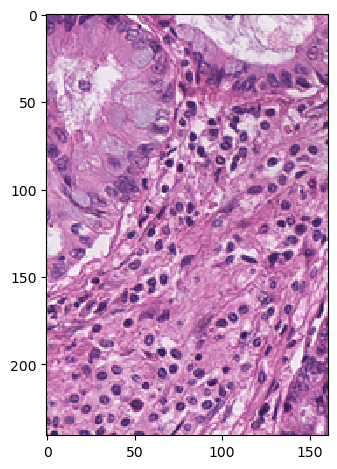

In [6]:
sample = training_set[0]
print(sample)
show_img(os.path.join(training_set_path, sample))

In [37]:
training_set[5]

'TCGA-53-A4EZ-01Z-00-DX1-26194-12319-[1, 1, 0].png'

In [38]:
'-'.join(training_set[5][:-4].split("-")[0:6])

'TCGA-53-A4EZ-01Z-00-DX1'

In [39]:
training_set[-1]

'1125346-28534-29911-[1, 1, 0].png'

In [7]:
training_features_list = [[],[],[],[],[],[],[]]
for row in training_set:
    try:
        features = row[:-4].split("-")
        if(len(features) < 5):
            training_features_list[0].append(features[0])
            training_features_list[1].append(features[1])
            training_features_list[2].append(features[2])
            training_features_list[3].append(ast.literal_eval(features[3])[0])
            training_features_list[4].append(ast.literal_eval(features[3])[1])
            training_features_list[5].append(ast.literal_eval(features[3])[2])
            training_features_list[6].append(ast.literal_eval(features[3]))
        else:
            training_features_list[0].append('-'.join(features[0:6]))
            training_features_list[1].append(features[6])
            training_features_list[2].append(features[7])
            training_features_list[3].append(ast.literal_eval(features[8])[0])
            training_features_list[4].append(ast.literal_eval(features[8])[1])
            training_features_list[5].append(ast.literal_eval(features[8])[2])
            training_features_list[6].append(ast.literal_eval(features[8]))
        
    except:
        print(f"Error: {row}")

In [8]:
training_features = pd.DataFrame(training_features_list).T
columns = columns=["id", "x_axis", "y_axis", "tumor", "stroma", "normal", "patch_level_multi_class_labels"]
training_features.columns = columns

training_features.to_csv("../../../../../mnt/data/WSSS4LUAD/features/training.csv")
training_features

,id,x_axis,y_axis,tumor,stroma,normal,patch_level_multi_class_labels
0,1121662,18689,51768,1,1,0,"[1, 1, 0]"
1,439448,40234,49182,0,1,0,"[0, 1, 0]"
2,439448,24841,49182,1,1,0,"[1, 1, 0]"
3,1200164,32198,20791,1,0,0,"[1, 0, 0]"
4,1124863,20231,19634,1,1,0,"[1, 1, 0]"
...,...,...,...,...,...,...,...
10086,1125346,12057,22971,1,1,0,"[1, 1, 0]"
10087,1221636,38625,55003,1,1,0,"[1, 1, 0]"
10088,1115849,40052,40098,1,1,0,"[1, 1, 0]"
10089,1121662,9620,13649,0,0,1,"[0, 0, 1]"


In [9]:
print(f"Normal: {(len(training_features[training_features['normal'] == 1])/len(training_features))*100}")
print(f"Tumor: {(len(training_features[(training_features['tumor'] ==  1) & (training_features['stroma'] == 0)])/len(training_features))*100}")
print(f"Stroma: {(len(training_features[(training_features['tumor'] ==  0) & (training_features['stroma'] == 1)])/len(training_features))*100}")
print(f"Tumor and Stroma: {(len(training_features[(training_features['tumor'] ==  1) & (training_features['stroma'] == 1)])/len(training_features))*100}")

Normal: 18.204340501436924
Tumor: 11.743137449212169
Stroma: 16.648498662174216
Tumor and Stroma: 53.45357249033792


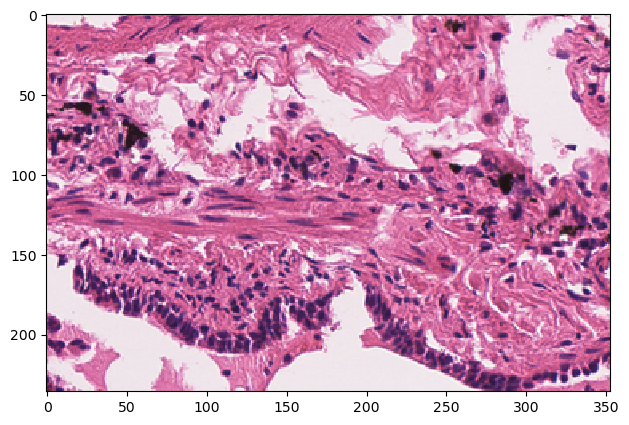

In [10]:
show_img(os.path.join(root_data_path, "WSSS4LUAD/2.validation/img/16.png"))

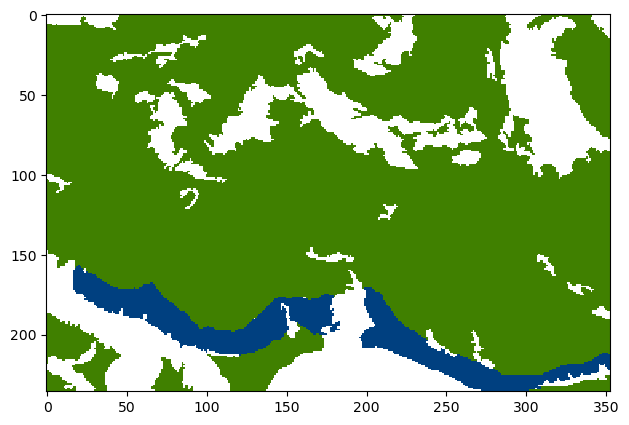

In [11]:
show_img(os.path.join(root_data_path, "WSSS4LUAD/2.validation/mask/16.png")) #Tumor: Blue, Stroma: Green, Normal: Yellow

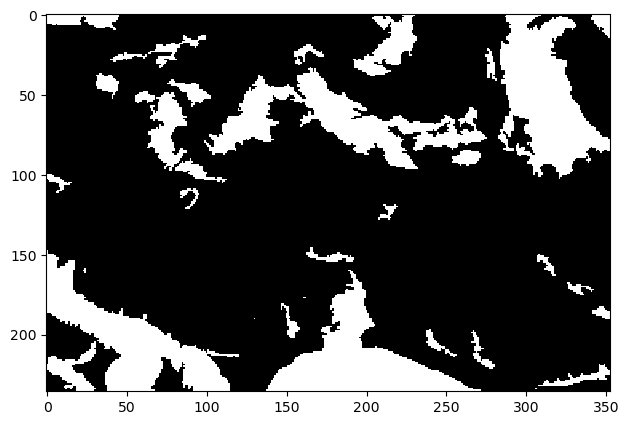

In [12]:
show_img(os.path.join(root_data_path, "WSSS4LUAD/2.validation/background-mask/16.png"))

In [13]:
valid_features = get_wss_features(os.path.join(root_data_path, "WSSS4LUAD/2.validation/mask"))
valid_features.to_csv("../../../../../mnt/data/WSSS4LUAD/features/validation.csv")

In [11]:
pd.read_csv("../../../../../mnt/data/WSSS4LUAD/features/validation_binary.csv", index_col=0)["patch_level_multi_class_labels"].value_counts()

patch_level_multi_class_labels
[0, 0, 1]    183
[0, 1, 0]    157
[1, 0, 0]    129
Name: count, dtype: int64

## DigestPath CTS

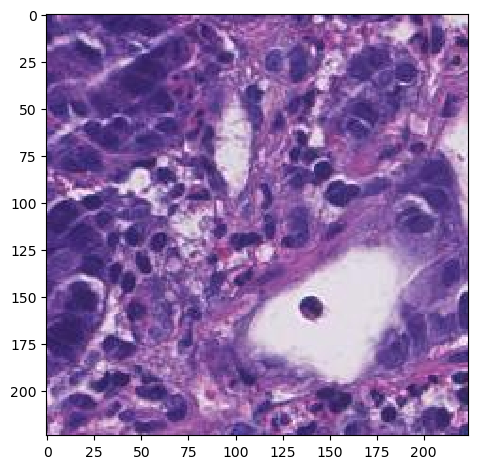

In [17]:
show_img(os.path.join(root_data_path, "DigestPath/Cancerous_WSI_patches/cancerous_patches/10.png"))

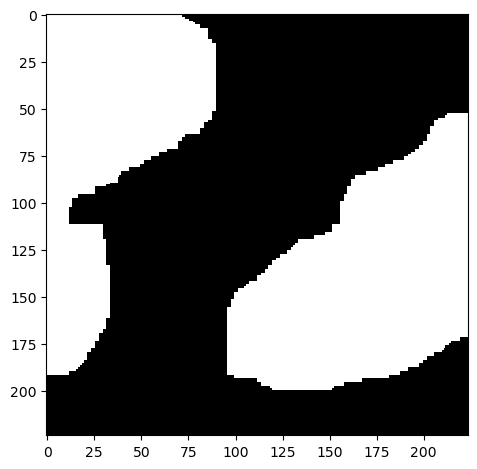

In [18]:
show_img(os.path.join(root_data_path, "DigestPath/Cancerous_WSI_patches/cancerous_patches/10_mask.png")) #White is malignant lesion

In [95]:
features = get_digestpath_features(root_data_path)
features.to_csv("../../../../../mnt/data/DigestPath/features.csv")
features

,id,patch_level_multi_class_labels,wsi_level_multi_class_labels
0,1_1_202,1,1
1,1_1_18295,1,1
2,1_1_8182,1,1
3,1_1_13573,1,1
4,1_1_8432,1,1
...,...,...,...
70374,0_0_772,0,0
70375,0_0_19575,0,0
70376,0_0_11370,0,0
70377,0_0_19502,0,0


## WSSS4LUAD Patient Level Class Matching

* Patch level class matching: check if patch_level_multi_class_labels are the same.
* Patient level class matching: check if patient-level-multi-class-labels are the same.

### Making Label

In [14]:
training_features = pd.read_csv("../../../../../mnt/data/WSSS4LUAD/features/training.csv", index_col=0)
valid_features = pd.read_csv("../../../../../mnt/data/WSSS4LUAD/features/validation.csv", index_col=0)

In [15]:
training_features = pd.read_csv("../../../../../mnt/data/WSSS4LUAD/features/training.csv", index_col=0)
valid_features = pd.read_csv("../../../../../mnt/data/WSSS4LUAD/features/validation.csv", index_col=0)

training_features = get_patient_level_multi_class_labels(training_features)
valid_features = get_patient_level_multi_class_labels(valid_features)

training_features.to_csv("../../../../../mnt/data/WSSS4LUAD/features/training.csv")
valid_features.to_csv("../../../../../mnt/data/WSSS4LUAD/features/validation.csv")
training_features

,id,x_axis,y_axis,tumor,stroma,normal,patch_level_multi_class_labels,patient_level_multi_class_labels
0,1121662,18689,51768,1,1,0,"[1, 1, 0]","[1, 1, 1]"
1,439448,40234,49182,0,1,0,"[0, 1, 0]","[1, 1, 1]"
2,439448,24841,49182,1,1,0,"[1, 1, 0]","[1, 1, 1]"
3,1200164,32198,20791,1,0,0,"[1, 0, 0]","[1, 1, 0]"
4,1124863,20231,19634,1,1,0,"[1, 1, 0]","[1, 1, 1]"
...,...,...,...,...,...,...,...,...
10086,1125346,12057,22971,1,1,0,"[1, 1, 0]","[1, 1, 1]"
10087,1221636,38625,55003,1,1,0,"[1, 1, 0]","[1, 1, 0]"
10088,1115849,40052,40098,1,1,0,"[1, 1, 0]","[1, 1, 0]"
10089,1121662,9620,13649,0,0,1,"[0, 0, 1]","[1, 1, 1]"


In [16]:
valid_features["patch_level_multi_class_labels"].value_counts()

patch_level_multi_class_labels
[1, 1, 0]    30
[1, 1, 1]     5
[0, 1, 0]     2
[0, 0, 1]     2
[1, 0, 1]     1
Name: count, dtype: int64

In [17]:
training_features["patient_level_multi_class_labels"].value_counts()

patient_level_multi_class_labels
[1, 1, 1]    5945
[1, 1, 0]    4146
Name: count, dtype: int64

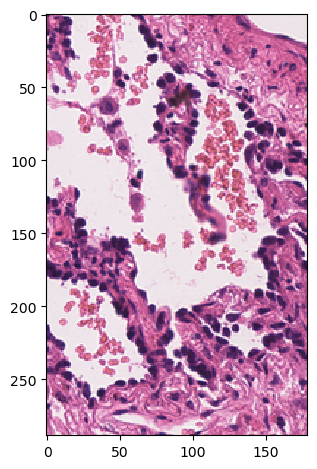

In [18]:
show_img("../../../../../../../mnt/data/WSSS4LUAD/1.training/1003370-11223-11698-[1, 1, 0].png")

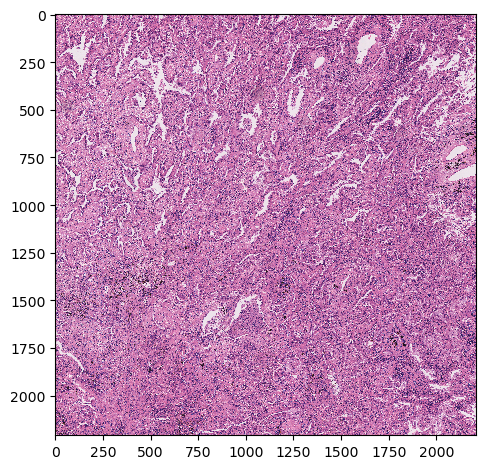

In [19]:
show_img("../../../../../../../mnt/data/WSSS4LUAD/2.validation/img/36.png")

In [20]:
training_features = pd.read_csv("../../../../../mnt/data/WSSS4LUAD/features/training.csv", index_col=0)
training_features.patch_level_multi_class_labels.value_counts()

patch_level_multi_class_labels
[1, 1, 0]    5393
[0, 0, 1]    1832
[0, 1, 0]    1680
[1, 0, 0]    1181
[1, 0, 1]       4
[1, 1, 1]       1
Name: count, dtype: int64

In [21]:
len(training_features.id.unique()) + len(valid_features.id.unique())

103

## WSSS4LUAD Binary

In [22]:
#Total = 10130
training_features = pd.read_csv("../../../../../mnt/data/WSSS4LUAD/features/training.csv", index_col=0)
valid_features = pd.read_csv("../../../../../mnt/data/WSSS4LUAD/features/validation.csv", index_col=0)

In [23]:
wsss4luad_binary_train = training_features[training_features['patch_level_multi_class_labels'].isin(["[1, 0, 0]", "[0, 1, 0]", "[0, 0, 1]"])]
wsss4luad_binary_val = valid_features[valid_features['patch_level_multi_class_labels'].isin(["[1, 0, 0]", "[0, 1, 0]", "[0, 0, 1]"])]

In [24]:
wsss4luad_binary_train["original_val"] = 0

/tmp/ipykernel_1345444/818409641.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wsss4luad_binary_train["original_val"] = 0


In [25]:
wsss4luad_binary_val["original_val"] = 1

/tmp/ipykernel_1345444/1237321681.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wsss4luad_binary_val["original_val"] = 1


In [26]:
wsss4luad_binary = pd.concat([wsss4luad_binary_train, wsss4luad_binary_val], axis=0, ignore_index=True)

In [27]:
wsss4luad_binary["positive"] = 1
for index, row in wsss4luad_binary.iterrows():
    if(row["patch_level_multi_class_labels"] == '[0, 0, 1]'):
        wsss4luad_binary.at[index, "positive"] = 0

wsss4luad_binary

,id,x_axis,y_axis,tumor,stroma,normal,patch_level_multi_class_labels,patient_level_multi_class_labels,original_val,x-axis,y-axis,positive
0,439448,40234.0,49182.0,0,1,0,"[0, 1, 0]","[1, 1, 1]",0,NaN,NaN,1
1,1200164,32198.0,20791.0,1,0,0,"[1, 0, 0]","[1, 1, 0]",0,NaN,NaN,1
2,439448,24841.0,52434.0,0,1,0,"[0, 1, 0]","[1, 1, 1]",0,NaN,NaN,1
3,449636,41971.0,44304.0,0,0,1,"[0, 0, 1]","[1, 1, 1]",0,NaN,NaN,0
4,TCGA-78-8662-01Z-00-DX1,82271.0,62903.0,1,0,0,"[1, 0, 0]","[1, 1, 1]",0,NaN,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...
4692,1121662,9620.0,13649.0,0,0,1,"[0, 0, 1]","[1, 1, 1]",0,NaN,NaN,0
4693,15,NaN,NaN,0,1,0,"[0, 1, 0]","[0, 1, 0]",1,NaN,NaN,1
4694,1,NaN,NaN,0,1,0,"[0, 1, 0]","[0, 1, 0]",1,NaN,NaN,1
4695,2,NaN,NaN,0,0,1,"[0, 0, 1]","[0, 0, 1]",1,NaN,NaN,0


In [28]:
wsss4luad_binary.positive.value_counts()

positive
1    2863
0    1834
Name: count, dtype: int64

In [29]:
wsss4luad_binary.to_csv("../../../../../mnt/data/WSSS4LUAD/features/binary.csv")

In [30]:
def sample_group(group):
    n_samples_per_group = wsss4luad_binary['positive'].value_counts().apply(lambda x: max(1, int(x * 0.1)))
    n_samples = n_samples_per_group[group.name]
    return group.sample(n=n_samples, random_state=1)

In [31]:
validation = wsss4luad_binary.groupby('positive').apply(sample_group).reset_index(drop=True)
valid_indices = validation.index

training = wsss4luad_binary.drop(valid_indices).reset_index(drop=True)

training.to_csv("../../../../../mnt/data/WSSS4LUAD/features/training_binary.csv")
validation.to_csv("../../../../../mnt/data/WSSS4LUAD/features/validation_binary.csv")

## Binary Slide level split

In [32]:
pd.read_csv("../../../../../mnt/data/WSSS4LUAD/features/training_binary.csv")["positive"].value_counts()

positive
1    2579
0    1649
Name: count, dtype: int64

In [33]:
pd.read_csv("../../../../../mnt/data/WSSS4LUAD/features/validation_binary.csv")["positive"].value_counts()

positive
1    286
0    183
Name: count, dtype: int64

In [34]:
pd.read_csv("../../../../../mnt/data/WSSS4LUAD/features/training_binary.csv")

,Unnamed: 0,id,x_axis,y_axis,tumor,stroma,normal,patch_level_multi_class_labels,patient_level_multi_class_labels,original_val,x-axis,y-axis,positive
0,0,1222870,19356.0,5339.0,0,0,1,"[0, 0, 1]","[1, 1, 1]",0,NaN,NaN,0
1,1,1222870,20161.0,12503.0,0,0,1,"[0, 0, 1]","[1, 1, 1]",0,NaN,NaN,0
2,2,1031280,12488.0,28806.0,1,0,0,"[1, 0, 0]","[1, 1, 0]",0,NaN,NaN,1
3,3,1114839,18974.0,31521.0,1,0,0,"[1, 0, 0]","[1, 1, 1]",0,NaN,NaN,1
4,4,1021305,8179.0,31819.0,0,0,1,"[0, 0, 1]","[1, 1, 1]",0,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4223,4223,1121662,9620.0,13649.0,0,0,1,"[0, 0, 1]","[1, 1, 1]",0,NaN,NaN,0
4224,4224,15,NaN,NaN,0,1,0,"[0, 1, 0]","[0, 1, 0]",1,NaN,NaN,1
4225,4225,1,NaN,NaN,0,1,0,"[0, 1, 0]","[0, 1, 0]",1,NaN,NaN,1
4226,4226,2,NaN,NaN,0,0,1,"[0, 0, 1]","[0, 0, 1]",1,NaN,NaN,0


## Patch Cam

In [9]:
patch_cam_data = pd.read_csv("../../../../../mnt/data/patch_cam/pcamv1/camelyonpatch_level_2_split_train_meta.csv")
patch_cam_data

,Unnamed: 0,coord_y,coord_x,tumor_patch,center_tumor_patch,wsi
0,0,63104,43648,False,False,camelyon16_train_tumor_104
1,1,148544,74048,True,True,camelyon16_train_tumor_003
2,2,64192,78912,True,True,camelyon16_train_tumor_089
3,3,98048,72128,True,True,camelyon16_train_tumor_004
4,4,27264,50688,False,False,camelyon16_train_normal_118
...,...,...,...,...,...,...
262139,262139,164672,44160,True,True,camelyon16_train_tumor_025
262140,262140,155584,31296,True,True,camelyon16_train_tumor_042
262141,262141,28032,114944,True,True,camelyon16_train_tumor_101
262142,262142,51264,32960,False,False,camelyon16_train_normal_021


In [10]:
pd.value_counts(patch_cam_data["tumor_patch"])

/tmp/ipykernel_2631087/471782768.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(patch_cam_data["tumor_patch"])


tumor_patch
True     131745
False    130399
Name: count, dtype: int64

In [12]:
patch_cam_data = pd.read_csv("../../../../../mnt/data/patch_cam/pcamv1/camelyonpatch_level_2_split_valid_meta.csv")
pd.value_counts(patch_cam_data["tumor_patch"])

/tmp/ipykernel_2631087/1606860786.py:2: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(patch_cam_data["tumor_patch"])


tumor_patch
True     16458
False    16310
Name: count, dtype: int64

In [14]:
patch_cam_data = pd.read_csv("../../../../../mnt/data/patch_cam/pcamv1/camelyonpatch_level_2_split_test_meta.csv")
pd.value_counts(patch_cam_data["tumor_patch"])

/tmp/ipykernel_2631087/4146300932.py:2: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(patch_cam_data["tumor_patch"])


tumor_patch
True     16474
False    16294
Name: count, dtype: int64

In [4]:
path = "../../../../../../../mnt/data/patch_cam/pcamv1/camelyonpatch_level_2_split_train"
with h5py.File(f"{path}_x.h5", mode='r') as file:
    print(keys(file))
    print("x" in file)

['x']
True


In [5]:
image_data = []
diagnosis = []

with h5py.File(f"{path}_x.h5", mode='r') as file:
    dataset = file['x']
    for patch in dataset:
        image_data.append(
                patch[np.newaxis]                      
            )
        
with h5py.File(f"{path}_y.h5", mode='r') as file:
    dataset = file['y']
    for label in dataset:
        diagnosis.append(label.item())  

In [ ]:
image_data[0].shape

(1, 96, 96, 3)

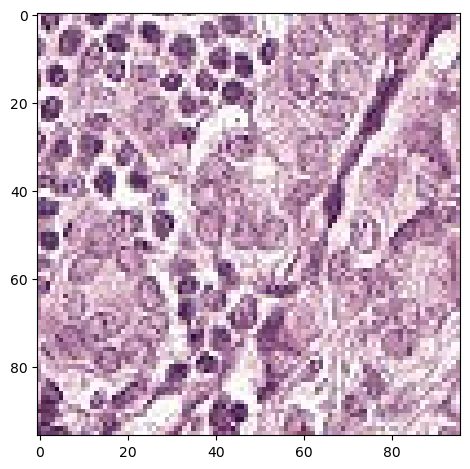

In [ ]:
io.imshow(image_data[1][0])


In [7]:
labels, counts = np.unique(diagnosis, return_counts=True)
print("Classes: ", pd.Series(counts, index=labels))

Classes:  0    131072
1    131072
dtype: int64


In [9]:
diagnosis[173487]

0

## Mhist

In [115]:
mhist = pd.read_csv("../../../../../media/research/data_slow/mhist/annnotations.csv")
mhist

,Image Name,Majority Vote Label,Number of Annotators who Selected SSA (Out of 7),Partition
0,MHIST_aaa.png,SSA,6,train
1,MHIST_aab.png,HP,0,train
2,MHIST_aac.png,SSA,5,train
3,MHIST_aae.png,HP,1,train
4,MHIST_aaf.png,SSA,5,train
...,...,...,...,...
3147,MHIST_cpn.png,SSA,7,train
3148,MHIST_cfc.png,SSA,7,test
3149,MHIST_cgp.png,SSA,7,test
3150,MHIST_dlf.png,SSA,7,train


In [116]:
mhist["Majority Vote Label"].unique()

array(['SSA', 'HP'], dtype=object)

In [117]:
mhist["Majority Vote Label"].value_counts()

Majority Vote Label
HP     2162
SSA     990
Name: count, dtype: int64

In [118]:
mhist["Partition"].unique()

array(['train', 'test'], dtype=object)

In [119]:
mhist["Majority Vote Label"] = mhist["Majority Vote Label"].apply(lambda x: 1 if x == "SSA" else '0')
mhist

,Image Name,Majority Vote Label,Number of Annotators who Selected SSA (Out of 7),Partition
0,MHIST_aaa.png,1,6,train
1,MHIST_aab.png,0,0,train
2,MHIST_aac.png,1,5,train
3,MHIST_aae.png,0,1,train
4,MHIST_aaf.png,1,5,train
...,...,...,...,...
3147,MHIST_cpn.png,1,7,train
3148,MHIST_cfc.png,1,7,test
3149,MHIST_cgp.png,1,7,test
3150,MHIST_dlf.png,1,7,train


In [120]:
mhist_train = mhist[mhist['Partition'] == "train"]
mhist_test = mhist[mhist['Partition'] == "test"]

In [121]:
print(mhist_train["Majority Vote Label"].value_counts())
print(mhist_test["Majority Vote Label"].value_counts())

Majority Vote Label
0    1545
1     630
Name: count, dtype: int64
Majority Vote Label
0    617
1    360
Name: count, dtype: int64


In [122]:
def sample_group(group):
    n_samples_per_group = mhist_train['Majority Vote Label'].value_counts().apply(lambda x: max(1, int(x * 0.1)))
    n_samples = n_samples_per_group[group.name]
    return group.sample(n=n_samples, random_state=1)

validation = mhist_train.groupby('Majority Vote Label').apply(sample_group)

valid_indices = validation.index.get_level_values(1)

training = mhist_train.drop(valid_indices).reset_index(drop=True)

validation = validation.reset_index(drop=True)


In [123]:
training["Majority Vote Label"].value_counts()

Majority Vote Label
0    1391
1     567
Name: count, dtype: int64

In [124]:
validation["Majority Vote Label"].value_counts()

Majority Vote Label
0    154
1     63
Name: count, dtype: int64

In [125]:
print(mhist_test["Majority Vote Label"].value_counts())

Majority Vote Label
0    617
1    360
Name: count, dtype: int64


In [9]:
images = {}
with ZipFile("../../../../../media/research/data_slow/mhist/images.zip", "r") as zip_ref:
   # Get list of files names in zip
   list_of_files = zip_ref.namelist()

   # Iterate over the list of file names in given list & print them
   for elem in list_of_files:
       #print(elem)
       ext = os.path.splitext(elem)[-1]  # Get extension of elem

       if ext == ".png":
           # Read data in case extension is ".jpg"
           in_bytes = zip_ref.read(elem)

           # Decode bytes to image.
           img = cv2.imdecode(np.frombuffer(in_bytes, np.uint8), cv2.IMREAD_COLOR)
           images[elem[7:]] = img

In [127]:
img.shape

(224, 224, 3)

In [128]:
len(images)

3152

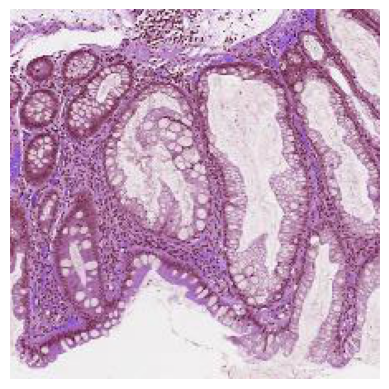

In [36]:
fig, ax = plt.subplots()
ax.imshow(list(images.values())[1389])

# Remove axes and border
ax.axis('off')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.get_xaxis().set_ticks([])
ax.get_yaxis().set_ticks([])

plt.show()

In [130]:
num_samples = len(training)
img_shape = img.shape

with h5py.File("../../../../../media/research/data_slow/mhist/mhist_train.h5", 'w') as h5_file:
    # Create datasets for images, labels, and partitions

    images_dset = h5_file.create_dataset('images', shape=(num_samples, *img_shape), dtype=np.uint8)
    labels_dset = h5_file.create_dataset('labels', shape=(num_samples,), dtype=np.int64)
    # Load images and store them in the HDF5 file
    for i, row in training.iterrows():
        try:
            images_dset[i] = images[row["Image Name"]]
            labels_dset[i] = row['Majority Vote Label']
        except:
            None

In [141]:
with h5py.File("../../../../../media/research/data_slow/mhist/mhist_train.h5", 'r') as h5_file:
    print(h5_file["images"])
    dataset = h5_file["images"][:]
    print(dataset.shape)
    random_row_indices = np.random.choice(dataset.shape[0], size=1000, replace=False)
    selected_rows = dataset[random_row_indices]
    print(selected_rows.shape)

<HDF5 dataset "images": shape (1958, 224, 224, 3), type "|u1">
(1958, 224, 224, 3)
(1000, 224, 224, 3)


## CRC

In [112]:
# Data loader ready

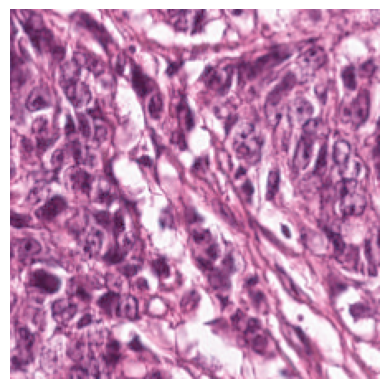

TIFF
(224, 224)
RGB


In [120]:
image = Image.open('../../../../../..//mnt/data/CRC/CRC-VAL-HE-7K/TUM/TUM-TCGA-AAHIDTWA.tif')

# Display the image
plt.imshow(image)
plt.axis('off')  # Hide axis
plt.show()

# Access image properties
print(image.format)  # Output: TIFF
print(image.size)    # Output: (width, height)
print(image.mode)    # Output: RGB, RGBA, L (grayscale), etc.

In [ ]:
pd.read_csv("../../../../../..//mnt/data/CRC/")

## CAMELYON17

In [103]:
#patient level slide matching
#stage level slide matching

# clam -> random/pca -> model feature -> similarity

In [22]:
camelyon = pd.read_csv("../../../../../../media/research/data_slow/CAMELYON17/CAMELYON17/stages.csv")
camelyon

,patient,stage,center
0,patient_000.zip,pN0,0
1,patient_000_node_0.tif,negative,0
2,patient_000_node_1.tif,negative,0
3,patient_000_node_2.tif,negative,0
4,patient_000_node_3.tif,negative,0
...,...,...,...
595,patient_099_node_0.tif,negative,4
596,patient_099_node_1.tif,negative,4
597,patient_099_node_2.tif,negative,4
598,patient_099_node_3.tif,negative,4


In [15]:
camelyon = camelyon[~camelyon['patient'].str.contains('.zip')]
camelyon

,patient,stage,center
1,patient_000_node_0.tif,negative,0
2,patient_000_node_1.tif,negative,0
3,patient_000_node_2.tif,negative,0
4,patient_000_node_3.tif,negative,0
5,patient_000_node_4.tif,negative,0
...,...,...,...
595,patient_099_node_0.tif,negative,4
596,patient_099_node_1.tif,negative,4
597,patient_099_node_2.tif,negative,4
598,patient_099_node_3.tif,negative,4


In [13]:
camelyon[~camelyon['patient'].str.contains('.zip')].to_csv("../../../../../../media/research/data_slow/CAMELYON17/CAMELYON17/slides.csv")

In [23]:
camelyon["stage"].value_counts()

stage
negative    318
macro        87
micro        59
itc          36
pN1          30
pN0          24
pN1mi        21
pN2          14
pN0(i+)      11
Name: count, dtype: int64

((96651, 197226), (48325, 98613), (24162, 49306), (12081, 24653), (6040, 12326), (3020, 6163), (1510, 3081), (755, 1540), (377, 770))


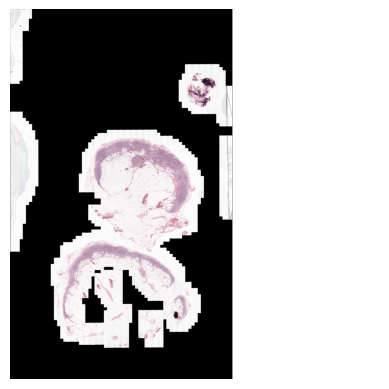

In [100]:
slide = openslide.OpenSlide('../../../../../../media/research/data_slow/CAMELYON17/CAMELYON17/images/patient_000_node_0.tif')
print(slide.level_dimensions)
# Define the region to read (x, y, width, height)
region = slide.read_region((0, 0), 5, (5024, 5024))

plt.imshow(region)
plt.axis('off')
plt.show()


<HDF5 dataset "imgs": shape (3908, 512, 512, 3), type "|u1">


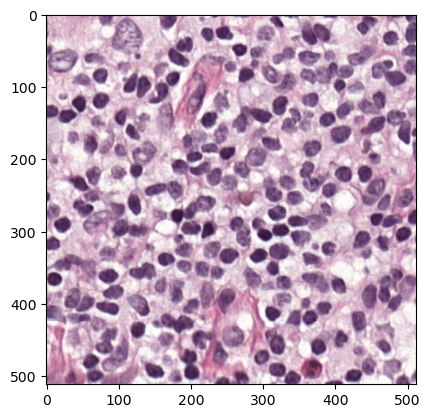

In [99]:
with h5py.File("../../../../../../media/research/data_slow/CAMELYON17/CAMELYON17/clam/patches/patient_000_node_0.h5", mode='r') as file:
    print(file["imgs"])
    plt.imshow(file["imgs"][1500])
    plt.axis('on')
    plt.show()
file.close()

((96651, 197226), (48325, 98613), (24162, 49306), (12081, 24653), (6040, 12326), (3020, 6163), (1510, 3081), (755, 1540), (377, 770))


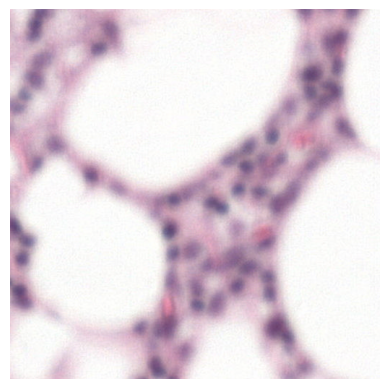

In [4]:
slide = openslide.OpenSlide('../../../../../../media/research/data_slow/CAMELYON17/CAMELYON17/images/patient_000_node_0.tif')
print(slide.level_dimensions)
# Define the region to read (x, y, width, height)
region = slide.read_region((71495, 126790), 0, (512, 512))

plt.imshow(region)
plt.axis('off')
plt.show()


In [5]:
sample = '../../../../../../media/research/data_slow/CAMELYON17/CAMELYON17/images/patient_000_node_0.tif'
slide = openslide.OpenSlide(sample)
device = "cuda"
root_dir = "../../../../../../media/research/data_slow/CAMELYON17/CAMELYON17/"
regions = []
            
with h5py.File(os.path.join(root_dir, f"clam/patches/patient_000_node_0.h5"), mode='r') as file:
    for coord in tqdm(file["coords"]):
        region = slide.read_region((coord[0], coord[1]), 0, (512, 512))
        region = np.array(region)
        region = np.expand_dims(region, axis=-1)
        region = np.transpose(region, (3, 0, 1, 2))
        # transformed_region = transform(region)
        transformed_region = region
        regions.append(transformed_region)

regions = np.array(regions, dtype=np.float32)
regions_tensor = torch.from_numpy(regions)

regions_tensor = regions_tensor.to(device, non_blocking=True)

100%|██████████| 22910/22910 [02:26<00:00, 156.44it/s]


OutOfMemoryError: CUDA out of memory. Tried to allocate 89.49 GiB. GPU 0 has a total capacty of 23.68 GiB of which 23.13 GiB is free. Process 1657305 has 298.00 MiB memory in use. Including non-PyTorch memory, this process has 254.00 MiB memory in use. Of the allocated memory 0 bytes is allocated by PyTorch, and 0 bytes is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting max_split_size_mb to avoid fragmentation.  See documentation for Memory Management and PYTORCH_CUDA_ALLOC_CONF

In [24]:
print(camelyon['stage'].value_counts(normalize=True))

train_df, test_df = train_test_split(camelyon, test_size=0.1, stratify=camelyon['stage'], random_state=42)
train_df, valid_df = train_test_split(train_df, test_size=0.1, stratify=train_df['stage'], random_state=42)

print(train_df['stage'].value_counts(normalize=True))
print(valid_df['stage'].value_counts(normalize=True))
print(test_df['stage'].value_counts(normalize=True))

stage
negative    0.530000
macro       0.145000
micro       0.098333
itc         0.060000
pN1         0.050000
pN0         0.040000
pN1mi       0.035000
pN2         0.023333
pN0(i+)     0.018333
Name: proportion, dtype: float64
stage
negative    0.528807
macro       0.144033
micro       0.098765
itc         0.059671
pN1         0.049383
pN0         0.041152
pN1mi       0.034979
pN2         0.024691
pN0(i+)     0.018519
Name: proportion, dtype: float64
stage
negative    0.537037
macro       0.148148
micro       0.092593
itc         0.055556
pN1         0.055556
pN0         0.037037
pN1mi       0.037037
pN0(i+)     0.018519
pN2         0.018519
Name: proportion, dtype: float64
stage
negative    0.533333
macro       0.150000
micro       0.100000
itc         0.066667
pN1         0.050000
pN0         0.033333
pN1mi       0.033333
pN0(i+)     0.016667
pN2         0.016667
Name: proportion, dtype: float64


In [25]:
train_df.to_csv("../../../../../../media/research/data_slow/CAMELYON17/CAMELYON17/train_slides.csv")
valid_df.to_csv("../../../../../../media/research/data_slow/CAMELYON17/CAMELYON17/valid_slides.csv")
test_df.to_csv("../../../../../../media/research/data_slow/CAMELYON17/CAMELYON17/test_slides.csv")

In [33]:
with h5py.File("../../../../../../media/research/data_slow/CAMELYON17/CAMELYON17/clam/patches/patient_000_node_0.h5", mode='r') as file:
    print(file["coords"][0])

[ 70215 127046]


In [53]:
slides = pd.read_csv(os.path.join("../../../../../../media/research/data_slow/CAMELYON17/CAMELYON17/", f"train_slides.csv"), index_col=0)
        
for index, row in slides.iterrows():
    print(row["patient"])
    print(row["stage"])
    break

patient_024_node_2.tif
itc


In [6]:
slides = pd.read_csv(os.path.join("../../../../../../media/research/data_slow/CAMELYON17/CAMELYON17/", f"test_slides.csv"), index_col=0)
slides[~slides['patient'].str.contains('.zip')].to_csv("../../../../../../media/research/data_slow/CAMELYON17/CAMELYON17/test_slides.csv")

In [4]:
files = next(os.walk("../../../../../../media/research/data_slow/CAMELYON17/CAMELYON17/clam/patches"))[2]
max_len = 0
max_id = ""
lengths = np.array([])
for file in files:
    with h5py.File(f"../../../../../../media/research/data_slow/CAMELYON17/CAMELYON17/clam/patches/{file}", mode='r') as data:
        lengths = np.append(lengths, len(data["coords"]))
        if len(data["coords"]) > max_len:
            max_len = len(data["coords"])
            max_id = file

print(file, max_len)

patient_006_node_1.h5 204176


In [5]:
lengths[::-1].sort()

In [18]:
lengths

array([204176., 169097., 164038., 158031., 156949., 155971., 149947.,
       147918., 145950., 144449., 143325., 137087., 129236., 127882.,
       126969., 125011., 124216., 124135., 123065., 122034., 119434.,
       118972., 118104., 117489., 116916., 116857., 116841., 116486.,
       116149., 115271., 114653., 113339., 112353., 111198., 109510.,
       107843., 106421., 106388., 105367., 104551., 104457., 104139.,
       103974., 103614., 103479., 102271., 102221., 101016., 100919.,
       100210., 100139., 100088.,  99543.,  99530.,  99282.,  98351.,
        98317.,  98016.,  97920.,  97876.,  97837.,  97607.,  96504.,
        96368.,  95838.,  95766.,  94310.,  93675.,  92857.,  92198.,
        92172.,  90749.,  89903.,  89812.,  89614.,  89564.,  89391.,
        89210.,  88714.,  86941.,  86890.,  86804.,  86787.,  86581.,
        86531.,  86263.,  86141.,  85974.,  85888.,  85847.,  85616.,
        85555.,  85110.,  84980.,  84702.,  84576.,  84572.,  84425.,
        84054.,  837

In [13]:
files = next(os.walk("../../../../../../media/research/data_slow/CAMELYON17/CAMELYON17/clam_small/patches"))[2]
max_len = 0
max_id = ""
lengths = np.array([])
for file in files:
    with h5py.File(f"../../../../../../media/research/data_slow/CAMELYON17/CAMELYON17/clam_small/patches/{file}", mode='r') as data:
        lengths = np.append(lengths, len(data["coords"]))
        if len(data["coords"]) > max_len:
            max_len = len(data["coords"])
            max_id = file

print(file, max_len)
lengths[::-1].sort()
lengths

StopIteration: 

In [17]:
sum(lengths)

7642423.0

## Camelyon16

In [37]:
camelyon16 = pd.read_csv("../../../../../../../../../../../../mnt/data/nfs03-R6/CAMELYON16/evaluation/reference.csv")
camelyon16 = camelyon16.rename(columns={'Unnamed: 0': 'image'})
camelyon16 = camelyon16.rename(columns={'image': 'id', 'type': 'label'})
camelyon16 = camelyon16.drop(columns=['class', 'center'])
camelyon16['split'] = camelyon16['id'].apply(lambda x: 'test' if x.startswith('test') else 'train')

train_data = camelyon16[camelyon16['split'] == 'train']
train_subset, valid_subset = train_test_split(train_data, 
                                             test_size=0.1, 
                                             stratify=train_data['label'], 
                                             random_state=42)

valid_ids = valid_subset['id'].tolist()
camelyon16.loc[camelyon16['id'].isin(valid_ids), 'split'] = 'valid'
camelyon16

,id,label,split
0,normal_001.tif,normal,train
1,normal_002.tif,normal,valid
2,normal_003.tif,normal,train
3,normal_004.tif,normal,train
4,normal_005.tif,normal,train
...,...,...,...
394,test_126.tif,normal,test
395,test_127.tif,normal,test
396,test_128.tif,normal,test
397,test_129.tif,normal,test


In [38]:
camelyon16["split"].value_counts()

split
train    243
test     129
valid     27
Name: count, dtype: int64

In [39]:
print(camelyon16[camelyon16['split'] == 'train']["label"].value_counts(normalize=True))
print(camelyon16[camelyon16['split'] == 'valid']["label"].value_counts(normalize=True))
print(camelyon16[camelyon16['split'] == 'test']["label"].value_counts(normalize=True))

label
normal    0.588477
tumor     0.411523
Name: proportion, dtype: float64
label
normal    0.592593
tumor     0.407407
Name: proportion, dtype: float64
label
normal    0.620155
tumor     0.379845
Name: proportion, dtype: float64


In [41]:
camelyon16['id'] = camelyon16['id'].str.replace('.tif', '', regex=False)
camelyon16

,id,label,split
0,normal_001,normal,train
1,normal_002,normal,valid
2,normal_003,normal,train
3,normal_004,normal,train
4,normal_005,normal,train
...,...,...,...
394,test_126,normal,test
395,test_127,normal,test
396,test_128,normal,test
397,test_129,normal,test


In [42]:
camelyon16.to_csv("../../../../../../../../../../../../mnt/data/nfs03-R6/CAMELYON16/waly_split_csv/split.csv")

In [4]:
final_data = pd.read_csv("../../../../../../../../../../../../mnt/data/nfs03-R6/CAMELYON16/waly_split_csv/split.csv", index_col=0)
final_data

,id,label,split
0,normal_001,normal,train
1,normal_002,normal,valid
2,normal_003,normal,train
3,normal_004,normal,train
4,normal_005,normal,train
...,...,...,...
394,test_126,normal,test
395,test_127,normal,test
396,test_128,normal,test
397,test_129,normal,test


In [6]:
final_test_data = final_data[final_data['split'] == 'test']
final_test_data = final_test_data.rename(columns={'id': 'file_name'})
final_test_data = final_test_data.drop(columns=['split'])
final_test_data['file_name'] = final_test_data['file_name'] + '.tif'
final_test_data.to_csv("../../yottixel/yottixel/yottixel_kimianet/yottixel_format_csv.csv")

In [7]:
pd.read_csv("../../yottixel/yottixel/yottixel_kimianet/yottixel_format_csv.csv", index_col=0)

,file_name,label
270,test_001.tif,tumor
271,test_002.tif,tumor
272,test_003.tif,normal
273,test_004.tif,tumor
274,test_005.tif,normal
...,...,...
394,test_126.tif,normal
395,test_127.tif,normal
396,test_128.tif,normal
397,test_129.tif,normal


 23%|██▎       | 455/1980 [00:05<00:17, 88.57it/s]  


KeyboardInterrupt: 

In [17]:
final_data["label"].value_counts()

label
normal    239
tumor     160
Name: count, dtype: int64

In [4]:
files = next(os.walk("../../../../../../../../../../../../mnt/nfs03-R6/CAMELYON16/clam_20/patches"))[2]
max_len = 0
max_id = ""
lengths = np.array([])
for file in files:
    with h5py.File(f"../../../../../../../../../../../../mnt/nfs03-R6/CAMELYON16/clam_20/patches/{file}", mode='r') as data:
        lengths = np.append(lengths, len(data["coords"]))
        if len(data["coords"]) > max_len:
            max_len = len(data["coords"])
            max_id = file

print(file, max_len)
lengths[::-1].sort()
lengths

normal_054.h5 24167


array([24167., 15360., 14082., 12617., 12097., 11734.,  8634.,  8562.,
        7986.,  7960.,  7727.,  6986.,  6924.,  6608.,  6590.,  6172.,
        5975.,  5893.,  5849.,  5748.,  5520.,  5485.,  5484.,  5340.,
        5334.,  5093.,  5072.,  5040.,  5028.,  4777.,  4775.,  4765.,
        4718.,  4692.,  4674.,  4622.,  4366.,  4356.,  4329.,  4272.,
        4229.,  4045.,  4042.,  3988.,  3974.,  3942.,  3931.,  3905.,
        3898.,  3879.,  3864.,  3848.,  3837.,  3831.,  3823.,  3805.,
        3759.,  3731.,  3643.,  3623.,  3605.,  3534.,  3500.,  3495.,
        3443.,  3440.,  3420.,  3392.,  3378.,  3363.,  3344.,  3315.,
        3310.,  3241.,  3214.,  3165.,  3162.,  3154.,  3145.,  3129.,
        3117.,  3109.,  3096.,  3063.,  3001.,  2931.,  2912.,  2879.,
        2877.,  2873.,  2873.,  2854.,  2829.,  2801.,  2790.,  2790.,
        2786.,  2771.,  2713.,  2704.,  2703.,  2658.,  2653.,  2641.,
        2641.,  2640.,  2619.,  2614.,  2573.,  2571.,  2569.,  2564.,
      

In [ ]:
files = next(os.walk("../../../../../../../../../../../../mnt/nfs03-R6/CAMELYON16/clam_20/patches"))[2]
max_len = 0
max_id = ""
lengths = np.array([])
for file in files:
    with h5py.File(f"../../../../../../media/research/data_slow/CAMELYON17/CAMELYON17/clam_small/patches/{file}", mode='r') as data:
        lengths = np.append(lengths, len(data["coords"]))
        if len(data["coords"]) > max_len:
            max_len = len(data["coords"])
            max_id = file

print(file, max_len)
lengths[::-1].sort()
lengths

In [46]:
melted_camelyon = camelyon.melt(id_vars=['id'], value_vars=['train', 'val', 'test'], var_name='split', value_name='is_true')
melted_camelyon = melted_camelyon[melted_camelyon['is_true']].drop(columns='is_true')
melted_camelyon

,id,split
0,normal_001,train
1,normal_003,train
2,normal_003,train
3,normal_004,train
4,normal_007,train
...,...,...
1192,tumor_013,test
1193,tumor_096,test
1194,tumor_065,test
1195,tumor_065,test


In [47]:
melted_camelyon["split"].value_counts()

split
train    243
test     130
val       26
Name: count, dtype: int64

In [61]:
melted_camelyon["id"][1193][:-4]

'tumor'

# BRACs

In [12]:
bracs_data = pd.read_excel("../../../../../../../../mnt/nfs03-R6/BRACS/BRACS.xlsx", index_col=None)
bracs_data = bracs_data[bracs_data["Set"]=="Testing"]
bracs_yottixel_data = bracs_data[["WSI Filename", "WSI label"]]
bracs_yottixel_data = bracs_yottixel_data.rename(columns={"WSI Filename":"file_name", "WSI label":"label"})
bracs_yottixel_data['file_name'] = bracs_yottixel_data['file_name'].astype(str) + '.svs'
bracs_yottixel_data.to_csv("./bracs_yottixel_data.csv")

# BRACs lvl 2

In [4]:
bracs_data = pd.read_excel("../../../../../../../../mnt/nfs03-R6/BRACS/BRACS.xlsx", index_col=None)
bracs_data = bracs_data[bracs_data["Set"]=="Testing"]
bracs_yottixel_data = bracs_data[["WSI Filename", "WSI label"]]
bracs_yottixel_data = bracs_yottixel_data.rename(columns={"WSI Filename":"file_name", "WSI label":"label"})
bracs_yottixel_data['file_name'] = bracs_yottixel_data['file_name'].astype(str) + '.svs'
mapping_dict = {'PB': 'BT', 'UDH': 'BT', 'IC': 'MT', 'FEA': 'AT', 'DCIS': 'MT', 'ADH': 'AT', 'N': 'BT'}
bracs_yottixel_data['label'] = bracs_yottixel_data['label'].replace(mapping_dict)
bracs_yottixel_data.to_csv("./bracs_lvl_2_yottixel_data.csv")

# End

In [37]:
with h5py.File(os.path.join("../../../../../../../../media/research/data_slow/CAMELYON17/CAMELYON17/feature_vectors/UNI/", "patient_026_node_0.h5"), mode='r') as file:
            dataset = file['feature_vector'][:]
            

In [15]:
with h5py.File("../../../../../../media/research/data_slow/CAMELYON17/CAMELYON17/clam_small/patches/patient_059_node_0.h5", mode='r') as file:
            dataset = file['coords'][:]
dataset

array([[58752, 95488],
       [58752, 96000],
       [59264, 95488],
       ...,
       [54528,  9088],
       [49408,  7872],
       [49920,  7872]])

In [11]:
with h5py.File("../../../../../../mnt/data/nfs03-R6/CAMELYON17/additional_features/feature_vectors/pca/camelyon_pca_deit_tiny_patch16_224/patient_000_node_2.h5", mode='r') as file:
            dataset = file['feature_vector'][:]
dataset.shape

(3189, 192)

In [12]:
with h5py.File("../../../../../../mnt/data/nfs03-R6/CAMELYON17/additional_features/feature_vectors/attn/camelyon_pca_deit_tiny_patch16_224/patient_000_node_2.h5", mode='r') as file:
            dataset = file['feature_vector'][:]
dataset.shape

(3189, 196, 192)

In [18]:
test = [dataset.flatten(), dataset.flatten(), dataset.flatten()]
test = np.asarray(test)
print(test.shape)
test = np.concatenate(test, axis=0)
print(test.shape)

(3, 120008448)
(360025344,)


In [6]:
x = []
y = []
for i in range(4):
    j = int(i)
    t = np.array([j,j,j,j])
    if len(x) == 0:
        x = np.array([j,j,j,j])
    else:
        x = np.concatenate((x, t))

for i in range(4):
    j = int(i)
    t = np.array([j,j,j,j])
    y.append(t)

# y = np.concatenate(y, axis=0)
print(x)
print(y)

[0 0 0 0 1 1 1 1 2 2 2 2 3 3 3 3]
[array([0, 0, 0, 0]), array([1, 1, 1, 1]), array([2, 2, 2, 2]), array([3, 3, 3, 3])]


In [8]:
slide_feat = []
slides_feat = []

for slide in range(5):
    for sample in range(3):
        slide_feat.append(int(sample))

    slides_feat.append(slide_feat)

slides_feat

[[0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2],
 [0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2],
 [0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2],
 [0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2],
 [0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2]]